In [1]:
from google.colab import files
uploaded = files.upload()   # faces.pkl seç

Saving faces.pkl to faces.pkl


In [2]:
import pickle, numpy as np, tensorflow as tf

with open("faces.pkl", "rb") as f:
    data_np = pickle.load(f)

In [3]:
import tensorflow as tf

BATCH_SIZE = 256
data = tf.data.Dataset.from_tensor_slices(data_np).shuffle(10000).batch(BATCH_SIZE)

In [4]:
from generator import build_generator
from discriminator import build_discriminator

shape = 64
channel = 3
NOISE_SIZE = 100

gen = build_generator(channel=channel, noise_size=NOISE_SIZE)
dis = build_discriminator(shape=shape, channel=channel)

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def dis_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def gen_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_opt = tf.keras.optimizers.Adam(1e-4)
dis_opt = tf.keras.optimizers.Adam(1e-4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
ckpt = tf.train.Checkpoint(
    gen=gen, dis=dis,
    gen_opt=gen_opt, dis_opt=dis_opt,
    epoch=tf.Variable(0)
)

manager = tf.train.CheckpointManager(
    ckpt,
    '/content/drive/MyDrive/HumanFaces/checkpoints',
    max_to_keep=5
)

if manager.latest_checkpoint:
    ckpt.restore(manager.latest_checkpoint).expect_partial()
    print("Yüklendi:", manager.latest_checkpoint, "epoch:", int(ckpt.epoch.numpy()))
else:
    print("Checkpoint yok, sıfırdan başlayacak.")

Yüklendi: /content/drive/MyDrive/HumanFaces/checkpoints/ckpt-6 epoch: 30


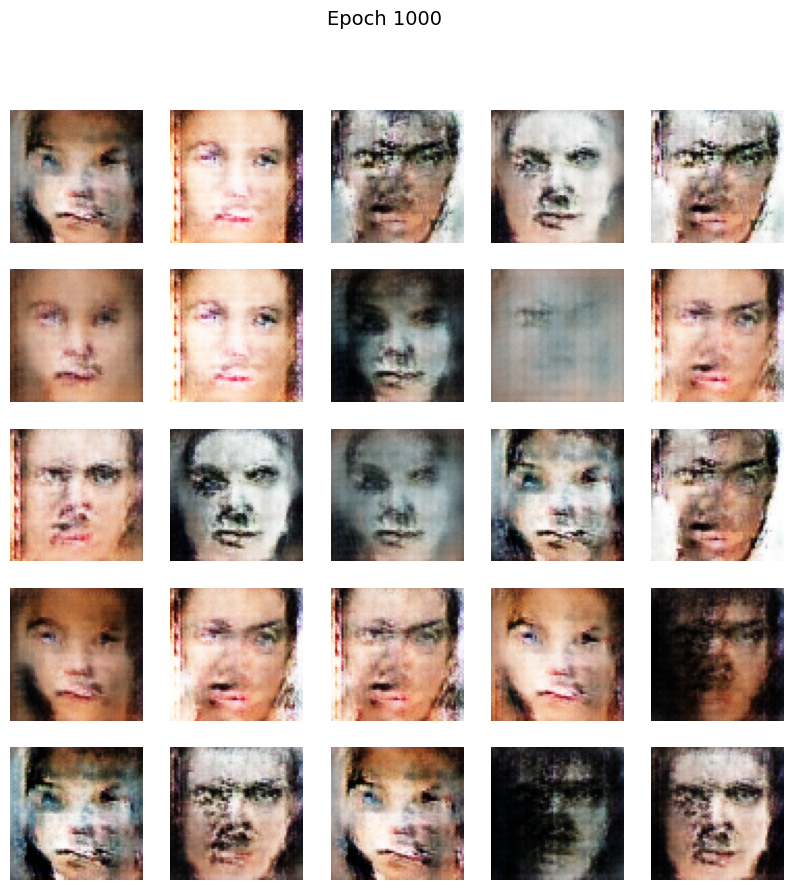

Epoch 1000 completed.
Checkpoint kaydedildi: /content/drive/MyDrive/HumanFaces/checkpoints/ckpt-200


In [10]:
from IPython import display
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_SIZE])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as dis_tape:
        generated_images = gen(noise, training=True)
        real_output = dis(images, training=True)
        fake_output = dis(generated_images, training=True)
        g_loss = gen_loss(fake_output)
        d_loss = dis_loss(real_output, fake_output)

    gen_grads = gen_tape.gradient(g_loss, gen.trainable_variables)
    dis_grads = dis_tape.gradient(d_loss, dis.trainable_variables)
    gen_opt.apply_gradients(zip(gen_grads, gen.trainable_variables))
    dis_opt.apply_gradients(zip(dis_grads, dis.trainable_variables))

def show_generated_images(model, epoch, seed, shape=64, channel=3):
    preds = model(seed, training=False)
    fig = plt.figure(figsize=(10, 10))
    for i in range(preds.shape[0]):
        plt.subplot(5, 5, i + 1)
        img = (preds[i] * 127.5 + 127.5).numpy().reshape(shape, shape, channel).astype("uint8")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
    plt.suptitle(f"Epoch {epoch}", fontsize=14)
    plt.show()

TARGET_EPOCH = 1000
start_epoch = int(ckpt.epoch.numpy())
seed = tf.random.normal([25, NOISE_SIZE])

for epoch in range(start_epoch, TARGET_EPOCH):
    for image_batch in data:
        train_step(image_batch)

    ckpt.epoch.assign(epoch + 1)

    display.clear_output(wait=True)
    show_generated_images(gen, epoch + 1, seed, shape=shape, channel=channel)
    print(f"Epoch {epoch + 1} completed.")

    if (epoch + 1) % 5 == 0:
        save_path = manager.save()
        print(f"Checkpoint kaydedildi: {save_path}")

In [11]:
gen.save('/content/drive/MyDrive/HumanFaces/generator.keras')
dis.save('/content/drive/MyDrive/HumanFaces/discriminator.keras')
print("Final modeller kaydedildi.")

Final modeller kaydedildi.


In [18]:
# Hugging Face CLI'ı yükleyin
!pip install huggingface-hub

# Veya doğrudan programatik olarak token ayarlayın


In [21]:
from huggingface_hub import HfApi, login
import json
import os

login()

# 1. Repository oluşturun (eğer yoksa)
repo_id = 'virtuerdem/gan-human-faces'
api = HfApi()

# 2. Model config dosyası oluşturun
config = {
    'architecture': 'GAN',
    'generator_type': 'Conv2DTranspose',
    'discriminator_type': 'Conv2D',
    'input_shape': [64, 64, 3],  # Veya kendi shape'iniz
    'latent_dim': 100,
    'loss_function': 'binary_crossentropy'
}

with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)

# 3. README oluşturun
readme_content = """---
library_name: keras
tags:
- gan
- generative
- human-faces
language:
- en
---

# GAN: Human Faces Generator

A Generative Adversarial Network trained to generate human faces.

## Model Details

- **Generator**: Keras model (.keras)
- **Discriminator**: Keras model (.keras)
- **Framework**: TensorFlow/Keras
- **Input dimension**: 100 (latent space)
- **Output**: 64x64 RGB images

## Usage

```python
import tensorflow as tf

# Model yükleyin
gen = tf.keras.models.load_model('generator.keras')

# Rastgele latent vector oluşturun
import numpy as np
z = np.random.normal(0, 1, (1, 100))

# Face generate edin
fake_face = gen.predict(z)
```

## Training Details

- Trained on: kaggle~~
- Epochs: 1000
- Batch size: 256
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

# 4. Tüm dosyaları push edin
api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/HumanFaces/generator.keras',
    path_in_repo='generator.keras',
    repo_id=repo_id,
    repo_type='model'
)

api.upload_file(
    path_or_fileobj='/content/drive/MyDrive/HumanFaces/discriminator.keras',
    path_in_repo='discriminator.keras',
    repo_id=repo_id,
    repo_type='model'
)

api.upload_file(
    path_or_fileobj='config.json',
    path_in_repo='config.json',
    repo_id=repo_id,
    repo_type='model'
)

api.upload_file(
    path_or_fileobj='README.md',
    path_in_repo='README.md',
    repo_id=repo_id,
    repo_type='model'
)

print("✓ Model ve metadata Hugging Face Hub'a yüklendi.")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...umanFaces/generator.keras:   2%|1         |  560kB / 28.1MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...Faces/discriminator.keras:   9%|8         |  556kB / 6.31MB            

Model ve metadata Hugging Face Hub'a yüklendi.
